In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings
filterwarnings("ignore")

import os
import sys
import traceback
import random
from typing import List, Dict, Callable

import torch
from tqdm import tqdm
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM, AutoModelForTokenClassification,
    DataCollatorForTokenClassification, DataCollatorForSeq2Seq,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    Trainer, TrainingArguments
)

from datasets import Dataset, DatasetDict
import collections

In [ ]:
#Dataset loading
!pip install datasets==2.14.5
from datasets import load_dataset

#ds = load_dataset("ai4bharat/naamapadam", "te") # "te" for telugu, "as" for assamese, "ta" -->tamil, "hi" -->hindi, "mr" -->Marathi, "kn" -->Kannada, "or" -->Oriya, "pa" -->Punjabi

# Try loading the dataset from the huggingface hub directly
ds = load_dataset("ai4bharat/naamapadam", "te")

print(ds)
print(ds["train"][0])

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 507741
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 847
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 2700
    })
})
{'tokens': ['స్థాపించబడిన', 'సాఫ్ట్వేర్'], 'ner_tags': [3, 0]}


Entity Distribution in Original Training Data:


,Count,Percentage
LOC,249075,19.706595
ORG,378581,29.952995
PER,636261,50.340410


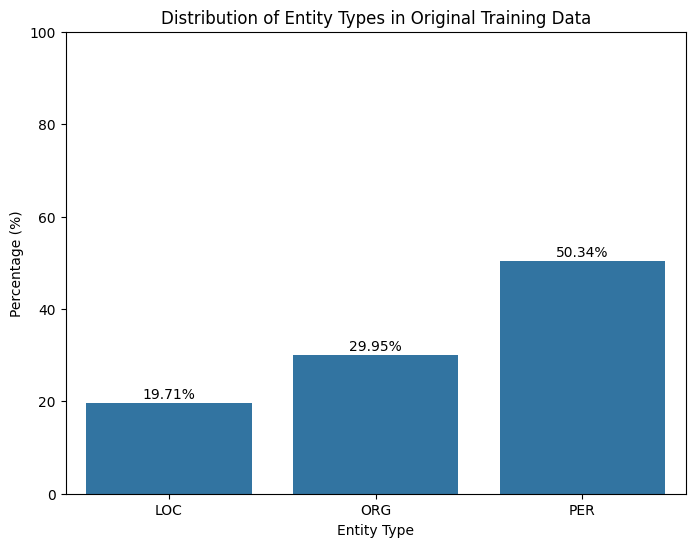

In [ ]:
# Map label ids to coarse entity types (ignore B/I distinction)
LABEL_TO_ENTITY = {
    0: None,    # O
    1: "PER",   # B-PER
    2: "PER",   # I-PER
    3: "ORG",   # B-ORG
    4: "ORG",   # I-ORG
    5: "LOC",   # B-LOC
    6: "LOC",   # I-LOC
}

# Calculate entity distribution in the original training data
import collections
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
entity_counts = collections.Counter()
total_entity_tags = 0

for ner_tags in ds['train']['ner_tags']:
    for tag in ner_tags:
        entity_type = LABEL_TO_ENTITY.get(tag, None)
        if entity_type:
            entity_counts[entity_type] += 1
            total_entity_tags += 1

# Create a DataFrame for the table
entity_distribution_df = pd.DataFrame.from_dict(entity_counts, orient='index', columns=['Count'])
entity_distribution_df['Percentage'] = (entity_distribution_df['Count'] / total_entity_tags) * 100
entity_distribution_df = entity_distribution_df.sort_index()

print("Entity Distribution in Original Training Data:")
display(entity_distribution_df)

# Create a bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=entity_distribution_df.index, y='Percentage', data=entity_distribution_df)
plt.title('Distribution of Entity Types in Original Training Data')
plt.xlabel('Entity Type')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100)

# Add percentage labels on the bars
for index, row in entity_distribution_df.iterrows():
    plt.text(index, row['Percentage'] + 1, f'{row["Percentage"]:.2f}%', color='black', ha="center")

plt.show()

In [ ]:
# sampling_naamapadam_hindi.py
SEED = 42
import random
random.seed(SEED)
import numpy as np
np.random.seed(SEED)
import collections

# --- Adjust these ---
N_TRAIN = 2000
N_VAL = 50
RANDOM_FRACTION = 0.5   # fraction of train that is pure-random
MIN_PER_ENTITY_TRAIN = 50  # minimum examples per entity type in train's entity-enriched half
MIN_PER_ENTITY_VAL = 5     # minimum examples per entity type in val
# -----------------------

def example_entity_types(ner_tags):
    """Return set of coarse entity types present in a sequence."""
    ents = set()
    for tag in ner_tags:
        ent = LABEL_TO_ENTITY.get(tag, None)
        if ent:
            ents.add(ent)
    return ents  # may be empty set()

def build_index_pools(dataset):
    """
    Build index lists:
      - all_indices: list of all example indices
      - entity_indices: indices that contain >=1 entity
      - per_entity_type: dict of entity_type -> list(indices)
    """
    all_indices = []
    entity_indices = []
    per_entity_type = collections.defaultdict(list)

    for i, ner_tags in enumerate(dataset['ner_tags']):
        all_indices.append(i)
        ents = example_entity_types(ner_tags)
        if len(ents) > 0:
            entity_indices.append(i)
            for e in ents:
                per_entity_type[e].append(i)

    return all_indices, entity_indices, per_entity_type

def safe_sample(pool, k):
    """Sample k items from pool without replacement, if pool smaller return all (shuffled)."""
    pool = list(pool)
    if len(pool) <= k:
        random.shuffle(pool)
        return pool
    return random.sample(pool, k)

def build_train_sample(ds_train, n_train=N_TRAIN,
                       random_fraction=RANDOM_FRACTION,
                       min_per_entity=MIN_PER_ENTITY_TRAIN):
    all_idx, entity_idx, per_entity = build_index_pools(ds_train)

    n_random = int(round(n_train * random_fraction))
    n_entity_enriched = n_train - n_random

    # 1) random part (draw from entire training set)
    random_part = safe_sample(all_idx, n_random)

    # 2) entity-enriched part: we try to distribute across entity types proportionally,
    #    but ensure at least min_per_entity per type (if possible)
    entity_types = list(per_entity.keys())
    if len(entity_types) == 0:
        # no entities in dataset? fall back to random
        entity_part = safe_sample(all_idx, n_entity_enriched)
    else:
        # compute available counts per type
        avail_counts = {e: len(per_entity[e]) for e in entity_types}
        total_avail = sum(avail_counts.values())

        # allocate desired counts proportional to availability
        raw_alloc = {e: int(round(n_entity_enriched * (avail_counts[e] / total_avail))) for e in entity_types}

        # enforce minimum floors
        for e in entity_types:
            if raw_alloc[e] < min_per_entity:
                raw_alloc[e] = min(min_per_entity, avail_counts[e])

        # adjust to sum to n_entity_enriched
        alloc_sum = sum(raw_alloc.values())
        # If too many, reduce from largest pools; if too few, add from remaining
        if alloc_sum != n_entity_enriched:
            # create sorted list by available spare (avail - alloc)
            diff = n_entity_enriched - alloc_sum
            # if diff > 0 we need to add, else remove
            # iterate entity_types sorted by avail_counts descending for adding, ascending for removing
            if diff > 0:
                sorted_types = sorted(entity_types, key=lambda e: avail_counts[e], reverse=True)
                i = 0
                while diff > 0:
                    e = sorted_types[i % len(sorted_types)]
                    if raw_alloc[e] < avail_counts[e]:
                        raw_alloc[e] += 1
                        diff -= 1
                    i += 1
            else:
                # need to remove - remove from largest allocated first but keep >=1
                diff = -diff
                sorted_types = sorted(entity_types, key=lambda e: raw_alloc[e], reverse=True)
                i = 0
                while diff > 0:
                    e = sorted_types[i % len(sorted_types)]
                    if raw_alloc[e] > 1:
                        raw_alloc[e] -= 1
                        diff -= 1
                    i += 1

        # now sample indices per entity type
        chosen = set()
        entity_part = []
        for e, cnt in raw_alloc.items():
            pool = per_entity[e]
            sel = safe_sample([idx for idx in pool if idx not in chosen], cnt)
            entity_part.extend(sel)
            chosen.update(sel)

        # If entity_part is short (due to overlaps or insufficient unique examples), fill from entity_idx
        if len(entity_part) < n_entity_enriched:
            remaining_needed = n_entity_enriched - len(entity_part)
            extra_pool = [i for i in entity_idx if i not in chosen]
            extra_sel = safe_sample(extra_pool, remaining_needed)
            entity_part.extend(extra_sel)
            chosen.update(extra_sel)

        # final safety: if still short (very unlikely), fill from all
        if len(entity_part) < n_entity_enriched:
            remaining_needed = n_entity_enriched - len(entity_part)
            extra_pool = [i for i in all_idx if i not in chosen]
            extra_sel = safe_sample(extra_pool, remaining_needed)
            entity_part.extend(extra_sel)
            chosen.update(extra_sel)

    # combine and ensure uniqueness and exact size
    train_indices = list(dict.fromkeys(random_part + entity_part))  # preserve order but unique
    # if duplicates removed made it smaller, fill up
    if len(train_indices) < n_train:
        needed = n_train - len(train_indices)
        pool = [i for i in all_idx if i not in train_indices]
        train_indices.extend(safe_sample(pool, needed))

    # if too large (shouldn't), truncate
    train_indices = train_indices[:n_train]
    random.shuffle(train_indices)
    return train_indices

def build_val_sample(ds_val, n_val=N_VAL, min_per_entity=MIN_PER_ENTITY_VAL):
    all_idx, entity_idx, per_entity = build_index_pools(ds_val)
    entity_types = list(per_entity.keys())

    val_indices = []
    if len(entity_types) == 0:
        # no entities in validation - fallback to random
        val_indices = safe_sample(all_idx, n_val)
    else:
        # allocate roughly equally among entity types, ensuring min_per_entity
        types_count = len(entity_types)
        per_type = max(min_per_entity, n_val // types_count)
        chosen = set()
        for e in entity_types:
            cnt = min(len(per_entity[e]), per_type) # Corrected line: removed extra parenthesis and added per_type
            sel = safe_sample([i for i in per_entity[e] if i not in chosen], cnt)
            val_indices.extend(sel)
            chosen.update(sel)

        # fill remaining slots from entity_idx (prefer entity containing)
        if len(val_indices) < n_val:
            need = n_val - len(val_indices)
            extra_pool = [i for i in entity_idx if i not in chosen]
            extra_sel = safe_sample(extra_pool, need)
            val_indices.extend(extra_sel)
            chosen.update(extra_sel)

        # if still short, fill from all
        if len(val_indices) < n_val:
            need = n_val - len(val_indices)
            extra_pool = [i for i in all_idx if i not in chosen]
            extra_sel = safe_sample(extra_pool, need)
            val_indices.extend(extra_sel)
            chosen.update(extra_sel)

    val_indices = val_indices[:n_val]
    random.shuffle(val_indices)
    return val_indices

# Example usage:
# assume ds is your DatasetDict already loaded (the one you printed)
# e.g. ds = load_from_disk(...) or load_dataset(...)
def sample_and_create_subsets(ds):
    train_ds = ds['train']
    val_ds = ds['validation']

    train_idx = build_train_sample(train_ds, n_train=N_TRAIN)
    val_idx = build_val_sample(val_ds, n_val=N_VAL)

    train_subset = train_ds.select(train_idx)
    val_subset = val_ds.select(val_idx)

    # Print diagnostics
    def count_entities(dataset):
        counter = collections.Counter()
        total_examples = len(dataset)
        entity_examples = 0
        for ner_tags in dataset['ner_tags']:
            ents = example_entity_types(ner_tags)
            if len(ents) > 0:
                entity_examples += 1
            for e in ents:
                counter[e] += 1
        return total_examples, entity_examples, dict(counter)

    t_total, t_entity_examples, t_counts = count_entities(train_subset)
    v_total, v_entity_examples, v_counts = count_entities(val_subset)

    print("Train subset size:", t_total)
    print("Train examples with >=1 entity:", t_entity_examples)
    print("Train per-entity-type counts (example-level):", t_counts)
    print()
    print("Val subset size:", v_total)
    print("Val examples with >=1 entity:", v_entity_examples)
    print("Val per-entity-type counts (example-level):", v_counts)

    return train_subset, val_subset

# If you have ds loaded, run:
train_subset, val_subset = sample_and_create_subsets(ds)

# Optionally save:
# train_subset.save_to_disk("bengali_train_2000")
# val_subset.save_to_disk("bengali_val_50")

Train subset size: 2000
Train examples with >=1 entity: 1746
Train per-entity-type counts (example-level): {'ORG': 697, 'LOC': 577, 'PER': 1017}

Val subset size: 50
Val examples with >=1 entity: 50
Val per-entity-type counts (example-level): {'ORG': 23, 'LOC': 25, 'PER': 29}


Entity Distribution in Sampled Training Data:


,Count,Percentage
LOC,1117,18.359632
ORG,1880,30.900723
PER,3087,50.739645


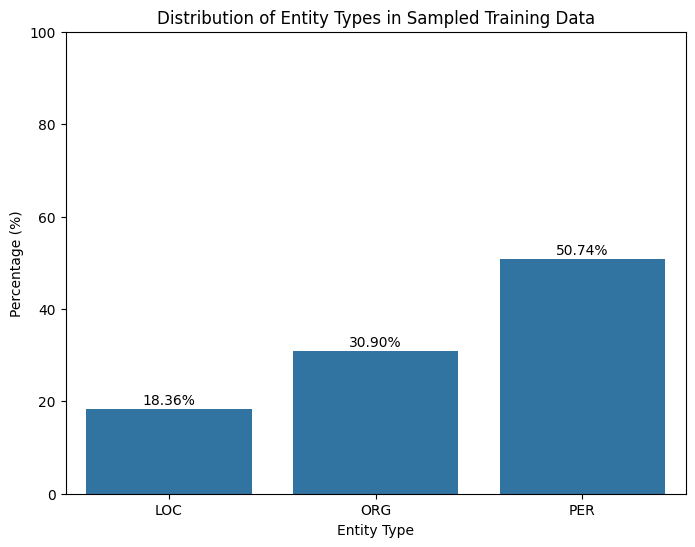

In [ ]:
# Calculate entity distribution in the sampled training subset
entity_counts = collections.Counter()
total_entity_tags = 0

for ner_tags in train_subset['ner_tags']:
    for tag in ner_tags:
        entity_type = LABEL_TO_ENTITY.get(tag, None)
        if entity_type:
            entity_counts[entity_type] += 1
            total_entity_tags += 1

# Create a DataFrame for the table
entity_distribution_df = pd.DataFrame.from_dict(entity_counts, orient='index', columns=['Count'])
entity_distribution_df['Percentage'] = (entity_distribution_df['Count'] / total_entity_tags) * 100
entity_distribution_df = entity_distribution_df.sort_index()

print("Entity Distribution in Sampled Training Data:")
display(entity_distribution_df)

# Create a bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=entity_distribution_df.index, y='Percentage', data=entity_distribution_df)
plt.title('Distribution of Entity Types in Sampled Training Data')
plt.xlabel('Entity Type')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100)

# Add percentage labels on the bars
for index, row in entity_distribution_df.iterrows():
    plt.text(index, row['Percentage'] + 1, f'{row["Percentage"]:.2f}%', color='black', ha="center")

plt.show()

In [ ]:
# -------------------------
# CustomException for easy debugging (uses sys.exc_info())
# -------------------------
import sys
from typing import List, Dict, Callable

class CustomException(Exception):
    def __init__(self, error_message, error_detail: sys):
        super().__init__(error_message)
        self.error_message = self.get_detailed_error_message(error_message, error_detail)

    @staticmethod
    def get_detailed_error_message(error_message, error_detail: sys):
        exc_type, exc_value, exc_tb = error_detail.exc_info()
        # Walk to last traceback frame
        tb = exc_tb
        while tb and tb.tb_next is not None:
            tb = tb.tb_next
        if tb:
            line_number = tb.tb_lineno
            file_name = tb.tb_frame.f_code.co_filename
            return f"Error in {file_name}, line {line_number}: {error_message} | {exc_type.__name__}: {exc_value}"
        return f"Error: {error_message} | {exc_type.__name__}: {exc_value}"

    def __str__(self):
        return self.error_message

# -------------------------
# Utilities: BIO -> spans (kept simple)
# -------------------------
def bio_to_spans(words: List[str], labels: List[int], id2label: Dict[int, str]):
    try:
        spans = []
        cur_type = None
        cur_start = None
        cur_tokens = []
        for i, lab in enumerate(labels):
            lab_name = id2label.get(lab, "O")
            if lab_name == "O":
                if cur_type is not None:
                    spans.append((" ".join(cur_tokens), cur_start, i - 1, cur_type))
                    cur_type = None
                    cur_start = None
                    cur_tokens = []
                continue
            if lab_name.startswith("B-"):
                if cur_type is not None:
                    spans.append((" ".join(cur_tokens), cur_start, i - 1, cur_type))
                cur_type = lab_name.split("-", 1)[1]
                cur_start = i
                cur_tokens = [words[i]]
            elif lab_name.startswith("I-"):
                ttype = lab_name.split("-", 1)[1]
                if cur_type == ttype:
                    cur_tokens.append(words[i])
                else:
                    if cur_type is not None:
                        spans.append((" ".join(cur_tokens), cur_start, i - 1, cur_type))
                    cur_type = ttype
                    cur_start = i
                    cur_tokens = [words[i]]
            else:
                if cur_type is not None:
                    spans.append((" ".join(cur_tokens), cur_start, i - 1, cur_type))
                    cur_type = None
                    cur_start = None
                    cur_tokens = []
        if cur_type is not None:
            spans.append((" ".join(cur_tokens), cur_start, len(labels) - 1, cur_type))
        return spans
    except Exception as e:
        print("[ERROR] Exception in bio_to_spans:")
        traceback.print_exc()
        raise CustomException("bio_to_spans failed", sys)

In [ ]:
import torch
torch.cuda.is_available()

True

In [ ]:
# -------------------------
# Evaluator (entity-level exact match)
# -------------------------
from typing import Callable, List, Dict
import sys
import traceback
from datasets import Dataset, DatasetDict # Added DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM, AutoModelForTokenClassification,
    DataCollatorForTokenClassification, DataCollatorForSeq2Seq,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    Trainer, TrainingArguments
)
from tqdm import tqdm
import torch # Added torch import

class NEREvaluator:
    def __init__(self, id2label: Dict[int, str]):
        self.id2label = id2label

    def evaluate(self, examples: List[Dict], predict_fn: Callable):
        try:
            n_correct = 0
            n_pos_pred = 0
            n_pos_gold = 0

            print("[INFO] Starting evaluation ...")
            for example in tqdm(examples, desc="Evaluating"):
                words = example["tokens"]
                gold_labels = example["ner_tags"]
                pred_labels = predict_fn(example)

                gold_spans = bio_to_spans(words, gold_labels, self.id2label)
                pred_spans = bio_to_spans(words, pred_labels, self.id2label)

                gold_set = set([(s, e, t, txt) for (txt, s, e, t) in gold_spans])
                pred_set = set([(s, e, t, txt) for (txt, s, e, t) in pred_spans])

                for p in pred_set:
                    if p in gold_set:
                        n_correct += 1
                    n_pos_pred += 1
                n_pos_gold += len(gold_set)

            prec = n_correct / (n_pos_pred + 1e-10)
            recall = n_correct / (n_pos_gold + 1e-10)
            f1 = 2 * prec * recall / (prec + recall + 1e-10)

            results = {"precision": prec, "recall": recall, "f1": f1,
                       "n_correct": n_correct, "n_pos_pred": n_pos_pred, "n_pos_gold": n_pos_gold}
            print("\n=== Evaluation Results ===")
            print(f"Correct spans: {n_correct}")
            print(f"Predicted spans: {n_pos_pred}")
            print(f"Gold spans: {n_pos_gold}")
            print(f"\nPrecision: {prec:.4f}  Recall: {recall:.4f}  F1: {f1:.4f}")
            return results
        except Exception as e:
            print("[ERROR] Exception during evaluation:")
            traceback.print_exc()
            raise CustomException("Evaluation failed", sys)

# -------------------------
# Base: TokenClassificationNER with print-based flow & exceptions
# -------------------------
class TokenClassificationNER:
    def __init__(self, model_name_or_path: str, label_list: List[str], device: str = None):
        self.model_name = model_name_or_path
        self.label_list = label_list
        self.id2label = {i: lab for i, lab in enumerate(label_list)}
        self.label2id = {lab: i for i, lab in enumerate(label_list)}
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.tokenizer = None
        self.model = None
        self.data_collator = None
        self.evaluator = NEREvaluator(self.id2label)

    def load_model(self):
        try:
            print(f"[INFO] Loading tokenizer and token-classification model: {self.model_name}")
            self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, use_fast=True)
            self.model = AutoModelForTokenClassification.from_pretrained(
                self.model_name,
                num_labels=len(self.label_list),
                id2label=self.id2label,
                label2id=self.label2id
            ).to(self.device)
            self.data_collator = DataCollatorForTokenClassification(self.tokenizer)
            print("[INFO] Model and tokenizer loaded successfully.")
        except Exception as e:
            print(f"[ERROR] Problem while loading model {self.model_name}: {e}")
            traceback.print_exc()
            raise CustomException(f"Loading model failed: {self.model_name}", sys)

    def tokenize_and_align_labels(self, dataset: Dataset):
        try:
            print("[INFO] Tokenization and label alignment started.")
            def _tokenize_and_align(examples):
                tokenized_inputs = self.tokenizer(examples["tokens"], is_split_into_words=True, truncation=True)
                all_labels = []
                for i, labels in enumerate(examples["ner_tags"]):
                    word_ids = tokenized_inputs.word_ids(batch_index=i)
                    previous_word_idx = None
                    label_ids = []
                    for word_idx in word_ids:
                        if word_idx is None:
                            label_ids.append(-100)
                        elif word_idx != previous_word_idx:
                            label_ids.append(labels[word_idx])
                        else:
                            lab_id = labels[word_idx]
                            lab_name = self.id2label[lab_id]
                            if lab_name.startswith("B-"):
                                new_lab = "I-" + lab_name.split("-", 1)[1]
                                label_ids.append(self.label2id.get(new_lab, lab_id))
                            else:
                                label_ids.append(lab_id)
                        previous_word_idx = word_idx
                    all_labels.append(label_ids)
                tokenized_inputs["labels"] = all_labels
                return tokenized_inputs
            tokenized = dataset.map(_tokenize_and_align, batched=True, remove_columns=dataset.column_names)
            print("[INFO] Tokenization completed.")
            return tokenized
        except Exception as e:
            print(f"[ERROR] Problem while tokenizing/aligning: {e}")
            traceback.print_exc()
            raise CustomException("Tokenization/label alignment failed", sys)

    def train(self, train_dataset: Dataset, val_dataset: Dataset, training_args: TrainingArguments):
        try:
            print("[INFO] Starting token-classification training using Trainer.")
            trainer = Trainer(
                model=self.model,
                args=training_args,
                train_dataset=train_dataset,
                eval_dataset=val_dataset,
                tokenizer=self.tokenizer,
                data_collator=self.data_collator
            )
            trainer.train()
            print("[INFO] Training completed.")
        except Exception as e:
            print(f"[ERROR] Problem during training: {e}")
            traceback.print_exc()
            raise CustomException("Training failed", sys)

    def predict_example(self, example: Dict):
        try:
            encoding = self.tokenizer(
                example["tokens"],
                is_split_into_words=True,
                return_offsets_mapping=False,
                return_tensors="pt",
                truncation=True,
                padding="max_length"
            )
            encoding = {k: v.to(self.device) for k, v in encoding.items()}
            with torch.no_grad():
                outputs = self.model(**encoding)
                logits = outputs.logits
                preds = torch.argmax(logits, dim=-1).squeeze().cpu().tolist()

            enc2 = self.tokenizer(example["tokens"], is_split_into_words=True, return_tensors="pt", truncation=True)
            word_ids = enc2.word_ids(batch_index=0)
            word_preds = []
            last_word_idx = None
            for idx, widx in enumerate(word_ids):
                if widx is None:
                    continue
                pred_label_id = preds[idx]
                if widx != last_word_idx:
                    word_preds.append(pred_label_id)
                    last_word_idx = widx
                else:
                    continue
            if len(word_preds) > len(example["tokens"]):
                word_preds = word_preds[:len(example["tokens"])]
            while len(word_preds) < len(example["tokens"]):
                word_preds.append(self.label2id.get("O", 0))
            return word_preds
        except Exception as e:
            print(f"[ERROR] Problem during prediction for example: {e}")
            traceback.print_exc()
            raise CustomException("Prediction failed (token-classification)", sys)

    def evaluate(self, dataset: Dataset):
        try:
            examples = list(dataset)
            return self.evaluator.evaluate(examples, self.predict_example)
        except Exception as e:
            print(f"[ERROR] Problem during evaluation: {e}")
            traceback.print_exc()
            raise CustomException("Evaluation failed (token-classification)", sys)

    def run(self, train_dataset: Dataset, val_dataset: Dataset, training_args: TrainingArguments = None, output_dir: str = "./outputs"):
        try:
            print(f"[RUN] Orchestration started for {self.model_name}")
            self.load_model()

            print("[RUN] Tokenizing and aligning train/val datasets ...")
            tokenized_train = self.tokenize_and_align_labels(train_dataset)
            tokenized_val = self.tokenize_and_align_labels(val_dataset)

            if training_args is None:
                training_args = TrainingArguments(
                    output_dir=output_dir,
                    per_device_train_batch_size=8,
                    per_device_eval_batch_size=8,
                    num_train_epochs=3,
                    learning_rate=2e-5,
                    logging_steps=50,
                    save_strategy="no",
                )

            print("[RUN] Training started.")
            self.train(tokenized_train, tokenized_val, training_args)

            print("[RUN] Evaluation started.")
            results = self.evaluate(val_dataset)
            print("[RUN] Orchestration completed.")
            return results

        except Exception as e:
            print(f"[ERROR] Problem in run orchestration: {e}")
            traceback.print_exc()
            raise CustomException("Run orchestration failed (token-classification)", sys)

# -------------------------
# Base: Seq2SeqNER with prints & exceptions
# -------------------------
class Seq2SeqNER:
    def __init__(self, model_name_or_path: str, id2label: Dict[int, str], device: str = None):
        self.model_name = model_name_or_path
        self.id2label = id2label
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.tokenizer = None
        self.model = None
        self.data_collator = None
        self.evaluator = NEREvaluator(self.id2label)

    def load_model(self):
        try:
            print(f"[INFO] Loading seq2seq model and tokenizer: {self.model_name}")
            self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, use_fast=True)
            self.model = AutoModelForSeq2SeqLM.from_pretrained(self.model_name).to(self.device)
            self.data_collator = DataCollatorForSeq2Seq(self.tokenizer, model=self.model)
            print("[INFO] Seq2seq model loaded.")
        except Exception as e:
            print(f"[ERROR] Problem while loading seq2seq model {self.model_name}: {e}")
            traceback.print_exc()
            raise CustomException("Loading seq2seq model failed", sys)

    def examples_to_texts(self, dataset: Dataset):
        try:
            inputs = []
            targets = []
            for ex in dataset:
                words = ex["tokens"]
                labels = ex["ner_tags"]
                # Updated input text format for Flan-T5 for better instruction following
                # if self.model_name == "google/flan-t5-base":
                #      input_text = 'Instruction: Extract named entities and their types from the Input. Return like "Entity:TYPE; ..." or "none".Example 1:Input: "রবীন্দ্রনাথ ঠাকুর কলকাতায় জন্মগ্রহণ করেছিলেন।"Output: "রবীন্দ্রনাথ ঠাকুর:PER; কলকাতা:LOC" Example 2:Input: "গুগল ক্যালিফোর্নিয়ায় প্রতিষ্ঠিত একটি প্রতিষ্ঠান।" Output: "গুগল:ORG; ক্যালিফোর্নিয়া:LOC" Example 3:Input: "মোতিজাহান ক্লিনিকে ভর্তি হয়েছেন।" Output: "মোতিজাহান:PER" Example 4: Input: "ভারত ১৯৪৭ সালে স্বাধীনতা লাভ করে।" Output: "none" Example 5:Input: "শেখ মুজিবুর রহমান বাংলাদেশের জাতীয় নেতা।" Output: "শেখ মুজিবুর রহমান:PER; বাংলাদেশ:LOC" Input: ' + " ".join(words) + " Output:"
                # else:
                input_text = "extract entities from sentence: " + " ".join(words)

                spans = bio_to_spans(words, labels, self.id2label)
                target_parts = []
                for txt, s, e, t in spans:
                    target_parts.append(f"{txt}:{t}")
                target_text = "; ".join(target_parts) if target_parts else "none" # Handle cases with no entities
                inputs.append(input_text)
                targets.append(target_text)
            print(f"\n[INFO] {len(inputs)} examples converted to texts.")
            print(f"\n[INFO] Input examples: {inputs[:5]}")
            print(f"\n[INFO] Target examples: {targets[:5]}")
            return inputs, targets
        except Exception as e:
            print(f"[ERROR] Problem while converting examples to texts: {e}")
            traceback.print_exc()
            raise CustomException("examples_to_texts failed", sys)

    def tokenize_for_seq2seq(self, dataset: Dataset, max_input_length=128, max_target_length=128):
        try:
            inputs, targets = self.examples_to_texts(dataset)
            # Create a temporary dataset from the generated texts to use the map function
            temp_dataset = Dataset.from_dict({"inputs": inputs, "targets": targets})

            def tokenize_batch(example):
                input_enc = self.tokenizer(example["inputs"], padding="max_length", truncation=True, max_length=max_input_length)
                target_enc = self.tokenizer(example["targets"], padding="max_length", truncation=True, max_length=max_target_length)

                input_enc["labels"] = target_enc["input_ids"]
                return input_enc

            # Map over the temporary dataset and remove the text columns after tokenization
            tokenized = temp_dataset.map(tokenize_batch, batched=True, remove_columns=['inputs', 'targets'])

            return tokenized
        except Exception as e:
            print(f"[ERROR] Problem during seq2seq tokenization: {e}")
            traceback.print_exc()
            raise CustomException("seq2seq tokenization failed", sys)


    def train(self, train_dataset, val_dataset, training_args: Seq2SeqTrainingArguments):
        try:
            print("[INFO] Starting seq2seq training using Seq2SeqTrainer.")
            trainer = Seq2SeqTrainer(
                model=self.model,
                args=training_args,
                train_dataset=train_dataset,
                eval_dataset=val_dataset,
                tokenizer=self.tokenizer,
                # data_collator=self.data_collator # Data collator is not needed for Seq2Seq when labels are provided
            )
            trainer.train()
            print("[INFO] Seq2seq training completed.")
        except Exception as e:
            print(f"[ERROR] Problem during seq2seq training: {e}")
            traceback.print_exc()
            raise CustomException("seq2seq training failed", sys)

    def predict_example(self, example: Dict, decode_max_length: int = 128):
        try:
            # Corrected input text format for prediction based on the training format
            if self.model_name == "google/flan-t5-base":
                input_text = 'Instruction: Extract named entities and their types from the Input. Return like "Entity:TYPE; ..." or "none".Example 1:Input: "রবীন্দ্রনাথ ঠাকুর কলকাতায় জন্মগ্রহণ করেছিলেন।"Output: "রবীন্দ্রনাথ ঠাকুর:PER; কলকাতা:LOC" Example 2:Input: "গুগল ক্যালিফোর্নিয়ায় প্রতিষ্ঠিত একটি প্রতিষ্ঠান।" Output: "গুগল:ORG; ক্যালিফোর্নিয়া:LOC" Example 3:Input: "মোতিজাহান ক্লিনিকে ভর্তি হয়েছেন।" Output: "মোতিজাহান:PER" Example 4: Input: "ভারত ১৯৪৭ সালে স্বাধীনতা লাভ করে।" Output: "none" Example 5:Input: "শেখ মুজিবুর রহমান বাংলাদেশের জাতীয় নেতা।" Output: "শেখ মুজিবুর রহমান:PER; বাংলাদেশ:LOC" Input: ' + " ".join(example["tokens"]) + " Output:"
            else:
                 input_text = "extract entities from sentence: " + " ".join(example["tokens"])

            enc = self.tokenizer(input_text, return_tensors="pt", truncation=True).to(self.device)
            with torch.no_grad():
                # Use generate with appropriate arguments
                gen_ids = self.model.generate(**enc, max_length=decode_max_length, num_beams=4, early_stopping=True) # Added num_beams and early_stopping for better generation
                gen_text = self.tokenizer.batch_decode(gen_ids, skip_special_tokens=True)[0]

            pred_spans = []
            # More robust parsing of generated text
            parts = [p.strip() for p in gen_text.replace(";", "|").split("|") if p.strip()]
            words = example["tokens"]
            for p in parts:
                if ":" in p:
                    try:
                        ent_text, ent_type = p.rsplit(":", 1)
                        ent_text = ent_text.strip()
                        ent_type = ent_type.strip()
                        ent_tokens = ent_text.split()

                        # Find span in original tokens - handle potential partial matches or variations
                        # Simple exact match first
                        found = False
                        for i in range(len(words) - len(ent_tokens) + 1):
                             if words[i:i + len(ent_tokens)] == ent_tokens:
                                 pred_spans.append((ent_text, i, i + len(ent_tokens) - 1, ent_type))
                                 found = True
                                 break
                        # Add fuzzy matching or other heuristics if needed for more robustness
                        # if not found:
                        #     print(f"Warning: Could not find span '{ent_text}' in original tokens.")


                    except ValueError:
                         # Handle cases where split(':') doesn't result in two parts
                         print(f"Warning: Could not parse entity part: {p}")
                         continue


            pred_labels = [0] * len(words)
            label2id = {v: k for k, v in self.id2label.items()}
            for txt, s, e, t in pred_spans:
                b_label = f"B-{t}"
                i_label = f"I-{t}"
                b_id = label2id.get(b_label, None)
                i_id = label2id.get(i_label, None)
                # Ensure labels are valid B- and I- tags before assigning
                if b_id is not None and i_id is not None:
                    pred_labels[s] = b_id
                    for idx in range(s + 1, e + 1):
                        pred_labels[idx] = i_id
                else:
                     # Fallback for unknown entity types generated by model
                     if t in label2id: # If it's a known type but not in BIO
                         pred_labels[s] = label2id[t] # Assign it as B-
                         for idx in range(s + 1, e + 1):
                              pred_labels[idx] = label2id[t] # Assign it as I- (using the same ID, might be wrong for true BIO)
                     else:
                        print(f"Warning: Unknown entity type '{t}' generated.")


            # Ensure length matches original tokens in case of truncation or other issues
            while len(pred_labels) < len(words):
                pred_labels.append(self.label2id.get("O", 0))
            if len(pred_labels) > len(words):
                 pred_labels = pred_labels[:len(words)]

            return pred_labels

        except Exception as e:
            print(f"[ERROR] Problem during seq2seq prediction: {e}")
            traceback.print_exc()
            raise CustomException("Prediction failed (seq2seq)", sys)


    def evaluate(self, dataset: Dataset):
        try:
            examples = list(dataset)
            return self.evaluator.evaluate(examples, self.predict_example)
        except Exception as e:
            print(f"[ERROR] Problem during seq2seq evaluation: {e}")
            traceback.print_exc()
            raise CustomException("Evaluation failed (seq2seq)", sys)

    def run(self, train_dataset: Dataset, val_dataset: Dataset, training_args: Seq2SeqTrainingArguments = None, output_dir: str = "./outputs_seq2seq"):
        try:
            print(f"[RUN] Orchestration started for seq2seq model {self.model_name}")
            self.load_model()

            print("[RUN] Converting examples to input/target text and tokenizing ...")
            tokenized_train = self.tokenize_for_seq2seq(train_dataset)
            tokenized_val = self.tokenize_for_seq2seq(val_dataset)


            if training_args is None:
                training_args = Seq2SeqTrainingArguments(
                    output_dir=output_dir,
                    # evaluation_strategy="epoch",
                    learning_rate=3e-5,
                    per_device_train_batch_size=2,
                    per_device_eval_batch_size=2,
                    num_train_epochs=3,
                    weight_decay=0.01,
                    save_total_limit=2,
                    predict_with_generate=True,
                    logging_dir="./logs"
                )

            print("[RUN] Starting seq2seq training ...")
            self.train(tokenized_train, tokenized_val, training_args)

            print("[RUN] Evaluating on validation set ...")
            results = self.evaluate(val_dataset)
            print("[RUN] Seq2seq orchestration completed.")
            return results

        except Exception as e:
            print(f"[ERROR] Problem in run orchestration (seq2seq): {e}")
            traceback.print_exc()
            raise CustomException("Run orchestration failed (seq2seq)", sys)

# -------------------------
# Concrete classes inheriting above
# -------------------------
class T5NER(Seq2SeqNER):
    def __init__(self, device: str = None):
        super().__init__("t5-base", id2label={0:"O",1:"B-PER",2:"I-PER",3:"B-ORG",4:"I-ORG",5:"B-LOC",6:"I-LOC"}, device=device)

class FlanT5NER(Seq2SeqNER):
    def __init__(self, device: str = None):
        super().__init__("google/flan-t5-base", id2label={0:"O",1:"B-PER",2:"I-PER",3:"B-ORG",4:"I-ORG",5:"B-LOC",6:"I-LOC"}, device=device)

class mT5NER(Seq2SeqNER):
    def __init__(self, device: str = None):
        super().__init__("google/mt5-base", id2label={0:"O",1:"B-PER",2:"I-PER",3:"B-ORG",4:"I-ORG",5:"B-LOC",6:"I-LOC"}, device=device)

class MBertNER(TokenClassificationNER):
    def __init__(self, device: str = None):
        label_list = ["O", "B-PER", "I-PER", "B-ORG", "I-ORG", "B-LOC", "I-LOC"]
        super().__init__("bert-base-multilingual-cased", label_list, device=device)

class XLMRNER(TokenClassificationNER):
    def __init__(self, device: str = None):
        label_list = ["O", "B-PER", "I-PER", "B-ORG", "I-ORG", "B-LOC", "I-LOC"]
        super().__init__("xlm-roberta-base", label_list, device=device)

In [ ]:
try:
    T5 = T5NER()
    T5results = T5.run(train_subset, val_subset)
except Exception as e:
    print(f"[ERROR] Error in example usage: {e}")
    traceback.print_exc()
    raise CustomException("Example usage failed", sys)

[RUN] Orchestration started for seq2seq model t5-base
[INFO] Loading seq2seq model and tokenizer: t5-base


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

...

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: shivanikomalla (shivanikomalla-rgukt-basar) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
500,0.523300
1000,0.052400
1500,0.046400
2000,0.045200
2500,0.044100
3000,0.043000


[INFO] Seq2seq training completed.
[RUN] Evaluating on validation set ...
[INFO] Starting evaluation ...


Evaluating: 100%|██████████| 50/50 [00:15<00:00,  3.25it/s]


=== Evaluation Results ===
Correct spans: 4
Predicted spans: 49
Gold spans: 98

Precision: 0.0816  Recall: 0.0408  F1: 0.0544
[RUN] Seq2seq orchestration completed.


In [ ]:
try:
    fT5 = FlanT5NER()
    fT5results = fT5.run(train_subset, val_subset)
except Exception as e:
    print(f"[ERROR] Error running FlanT5NER: {e}")

[RUN] Orchestration started for seq2seq model google/flan-t5-base
[INFO] Loading seq2seq model and tokenizer: google/flan-t5-base


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

/tmp/ipython-input-1290663396.py:308: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Step,Training Loss
500,2.989900
1000,0.052600
1500,0.045500
2000,0.044200
2500,0.043800
3000,0.041500


[INFO] Seq2seq training completed.
[RUN] Evaluating on validation set ...
[INFO] Starting evaluation ...


Evaluating: 100%|██████████| 50/50 [00:10<00:00,  4.97it/s]


=== Evaluation Results ===
Correct spans: 1
Predicted spans: 38
Gold spans: 98

Precision: 0.0263  Recall: 0.0102  F1: 0.0147
[RUN] Seq2seq orchestration completed.


In [ ]:
mT5 = mT5NER()
mT5results = mT5.run(train_subset, val_subset)

[RUN] Orchestration started for seq2seq model google/mt5-base
[INFO] Loading seq2seq model and tokenizer: google/mt5-base
[INFO] Seq2seq model loaded.
[RUN] Converting examples to input/target text and tokenizing ...

[INFO] 2000 examples converted to texts.

[INFO] Input examples: ['extract entities from sentence: ీకే అర్థమవుతుంది .', 'extract entities from sentence: సమీప జూనియర్ కళాశాల , ప్రభుత్వ ఆర్ట్స్ / సైన్స్ డిగ్రీ కళాశాల అవనిగడ్డలోను , ఇంజనీరింగ్ కళాశాల చల్లపల్లిలోనూ ఉన్నాయి .', 'extract entities from sentence: అన్న ప్రశ్న తరచూ నన్ను వేధించేది .', 'extract entities from sentence: అస్సాం , బీహార్ , ఉత్తర ప్రదేశ్ రాష్ట్రాల్లోని వరద బాధిత ప్రజలకు రెడ్ క్రాస్ సహాయక సరఫరాను జండా ఊపి ప్రారంభించిన - భారత రాష్ట్రపతి .', 'extract entities from sentence: ఢిల్లీలో కాలుష్యం']

[INFO] Target examples: ['none', 'ప్రభుత్వ ఆర్ట్స్ / సైన్స్ డిగ్రీ కళాశాల:ORG; అవనిగడ్డలోను:LOC; ఇంజనీరింగ్ కళాశాల చల్లపల్లిలోనూ:ORG', 'none', 'అస్సాం:LOC; బీహార్:LOC; ఉత్తర ప్రదేశ్:LOC; రెడ్ క్రాస్:ORG; ప్రారంభించిన

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]


[INFO] 50 examples converted to texts.

[INFO] Input examples: ['extract entities from sentence: వీరికి ఇద్దరు కుమార్తెలు శ్రీదేవి , శ్రీవిద్య .', 'extract entities from sentence: ఉపరాష్ట్రపతి వెంకయ్య నాయుడు , కేంద్ర మంత్రి రమేశ్ పోఖ్రియాల్ ఈ కార్యక్రమానికి హాజరైనా విద్యార్థుల మొర ఆలకించలేదు .', 'extract entities from sentence: బడ్జెట్లో కేంద్ర ఆర్థిక మంత్రి నిర్మలా సీతారామన్ ప్రవేశపెట్టిన బడ్జెట్లో .', 'extract entities from sentence: పంజాబ్ ముఖ్యమంత్రి ప్రకాష్సింగ్ బాదల్ ఘనవిజయం సాధించారు .', 'extract entities from sentence: సిబిఐ ఒక నిఘా సంస్థ - దర్యాప్తు సంస్థ .']

[INFO] Target examples: ['శ్రీదేవి:PER; శ్రీవిద్య:PER', 'వెంకయ్య నాయుడు:PER; కేంద్ర:ORG; రమేశ్ పోఖ్రియాల్:PER', 'నిర్మలా సీతారామన్:PER', 'పంజాబ్:LOC; ప్రకాష్సింగ్ బాదల్:PER', 'సిబిఐ:ORG']


Map:   0%|          | 0/50 [00:00<?, ? examples/s]

[RUN] Starting seq2seq training ...
[INFO] Starting seq2seq training using Seq2SeqTrainer.


Step,Training Loss
500,19.509100
1000,2.404200
1500,1.105200
2000,0.821700
2500,0.362200
3000,0.257100


[INFO] Seq2seq training completed.
[RUN] Evaluating on validation set ...
[INFO] Starting evaluation ...


Evaluating: 100%|██████████| 50/50 [00:15<00:00,  3.16it/s]


=== Evaluation Results ===
Correct spans: 2
Predicted spans: 19
Gold spans: 102

Precision: 0.1053  Recall: 0.0196  F1: 0.0331
[RUN] Seq2seq orchestration completed.


In [ ]:
mB = MBertNER()
mBresults = mB.run(train_subset, val_subset)

[RUN] Orchestration started for bert-base-multilingual-cased
[INFO] Loading tokenizer and token-classification model: bert-base-multilingual-cased


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: shivanikomalla (shivanikomalla-rgukt-basar) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
50,0.837100
100,0.537500
150,0.540100
200,0.463100
250,0.512400
300,0.353400
350,0.366100
400,0.351000
450,0.387400
500,0.341400


[INFO] Training completed.
[RUN] Evaluation started.
[INFO] Starting evaluation ...


Evaluating: 100%|██████████| 50/50 [00:01<00:00, 29.33it/s]


=== Evaluation Results ===
Correct spans: 80
Predicted spans: 122
Gold spans: 130

Precision: 0.6557  Recall: 0.6154  F1: 0.6349
[RUN] Orchestration completed.


In [ ]:
xlm = XLMRNER()
xlmresults = xlm.run(train_subset, val_subset)

[RUN] Orchestration started for xlm-roberta-base
[INFO] Loading tokenizer and token-classification model: xlm-roberta-base


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...

[INFO] Tokenization completed.
[RUN] Training started.
[INFO] Starting token-classification training using Trainer.


Step,Training Loss
50,1.172300
100,0.661000
150,0.622000
200,0.556400
250,0.505600
300,0.378000
350,0.416300
400,0.366400
450,0.412200
500,0.351100


[INFO] Training completed.
[RUN] Evaluation started.
[INFO] Starting evaluation ...


Evaluating: 100%|██████████| 50/50 [00:01<00:00, 29.46it/s]


=== Evaluation Results ===
Correct spans: 85
Predicted spans: 127
Gold spans: 130

Precision: 0.6693  Recall: 0.6538  F1: 0.6615
[RUN] Orchestration completed.


In [ ]:
fT52 = FlanT5NER()
fT52results = fT52.run(train_subset, val_subset)

[RUN] Orchestration started for seq2seq model google/flan-t5-base
[INFO] Loading seq2seq model and tokenizer: google/flan-t5-base


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

[RUN] Starting seq2seq training ...
[INFO] Starting seq2seq training using Seq2SeqTrainer.


Step,Training Loss
500,2.989900
1000,0.052600
1500,0.045500
2000,0.044200
2500,0.043800
3000,0.041500


[INFO] Seq2seq training completed.
[RUN] Evaluating on validation set ...
[INFO] Starting evaluation ...


Evaluating: 100%|██████████| 50/50 [00:10<00:00,  4.71it/s]


=== Evaluation Results ===
Correct spans: 2
Predicted spans: 37
Gold spans: 130

Precision: 0.0541  Recall: 0.0154  F1: 0.0240
[RUN] Seq2seq orchestration completed.


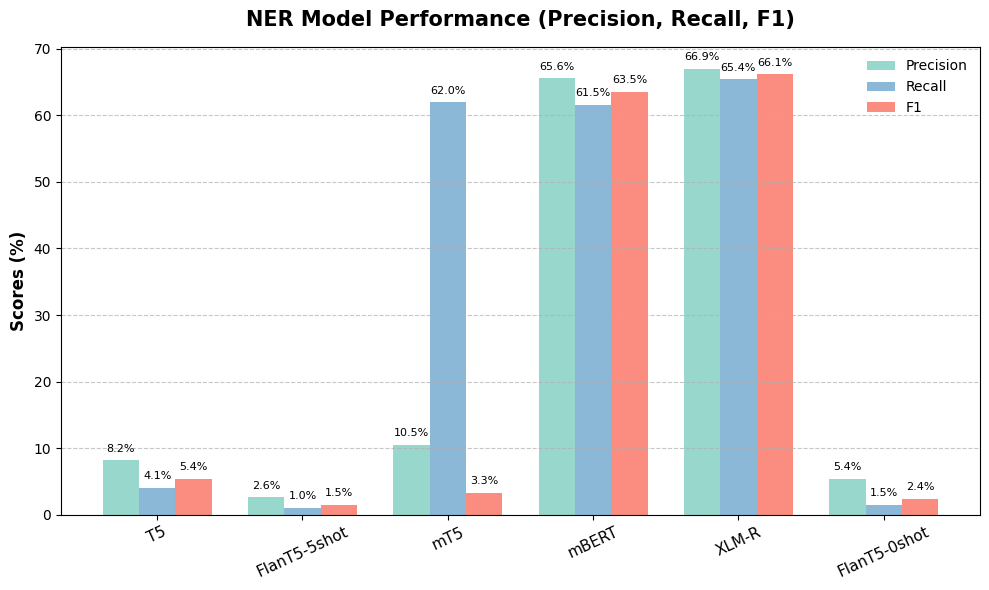

In [ ]:
# Results (converted to percentages)
T5results = {"Precision": 0.0816 , "Recall": 0.0408 , "F1": 0.0544}
fT5results = {"Precision": 0.0263 , "Recall": 0.0102, "F1": 0.0147}  # 5-shot
mT5results = {"Precision": 0.1053 ,"Recall": 0.6196, "F1": 0.0331}
mBresults = {"Precision": 0.6557 , "Recall": 0.6154  ,"F1": 0.6349}
xlmresults = {"Precision": 0.6693  ,"Recall": 0.6538 , "F1": 0.6615}
fT52results = {"Precision": 0.0541 , "Recall": 0.0154 , "F1": 0.0240} # zero-shot

models = ["T5", "FlanT5-5shot", "mT5", "mBERT", "XLM-R", "FlanT5-0shot"]
results = [T5results, fT5results, mT5results, mBresults, xlmresults, fT52results]

metrics = ["Precision", "Recall", "F1"]
colors = ["#8dd3c7", "#80b1d3", "#fb8072"]  # pastel green, blue, red

x = np.arange(len(models))  # model positions
width = 0.25  # bar width

fig, ax = plt.subplots(figsize=(10, 6))

for i, metric in enumerate(metrics):
    values = [res[metric]*100 for res in results]  # convert to %
    bars = ax.bar(x + i*width, values, width, label=metric, color=colors[i], alpha=0.9)

    # Add percentage text above bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

# Formatting
ax.set_ylabel("Scores (%)", fontsize=12, fontweight="bold")
ax.set_title("NER Model Performance (Precision, Recall, F1)", fontsize=15, fontweight="bold", pad=15)
ax.set_xticks(x + width)
ax.set_xticklabels(models, rotation=25, fontsize=11)
ax.legend(fontsize=10, frameon=False)

# Add gridlines for readability
ax.yaxis.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:
# Results (converted to percentages)
results = {
  "T5" : {"Precision": 0.0816 , "Recall": 0.0408 , "F1": 0.0544},
  "FlanT5-5shot" : {"Precision": 0.0263 , "Recall": 0.0102, "F1": 0.0147},
  "mT5" : {"Precision": 0.1053 ,"Recall": 0.0196, "F1": 0.0331},
  "mBERT" : {"Precision": 0.6557 , "Recall": 0.6154  ,"F1": 0.6349},
  "XLM-R" : {"Precision": 0.6693  ,"Recall": 0.6538 , "F1": 0.6615},
  "FlanT5-0shot" : {"Precision": 0.0541 , "Recall": 0.0154, "F1": 0.0240}
}

# Convert to DataFrame
results_df = pd.DataFrame(results).T * 100  # convert to %
results_df = results_df.round(2)

# Highlight the maximum in each column
def highlight_max(s):
    is_max = s == s.max()
    return ['font-weight: bold' if v else '' for v in is_max]

styled_df = results_df.style.format("{:.2f}").apply(highlight_max, subset=["Precision", "Recall", "F1"])

styled_df

,Precision,Recall,F1
T5,8.16,4.08,5.44
FlanT5-5shot,2.63,1.02,1.47
mT5,10.53,1.96,3.31
mBERT,65.57,61.54,63.49
XLM-R,66.93,65.38,66.15
FlanT5-0shot,5.41,1.54,2.40
